In [65]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [72]:
conn = sqlite3.connect(r'C:\Users\ronis\customer_churn.db')

sql_query = """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
"""

tables = pd.read_sql(sql_query,conn)

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * From {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe : df_{table_name}")

conn.close()

Created dataframe : df_db_customer
Created dataframe : df_db_subscription
Created dataframe : df_db_support


In [73]:
conn = sqlite3.connect(r'C:\Users\ronis\customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    columns_query = f"PRAGMA table_info({table_name});"
    columns= pd.read_sql(columns_query,conn)
    print("columns:")
    print(columns['name'].tolist())

conn.close()


Table Name: db_customer
columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [74]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [75]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [76]:
#rename col = Name
df_db_customer.rename(columns = {'name' : 'customer_name'},inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [77]:
# drop column = interest and pincode 
#df_db_customer.drop(df_db_customer.columns[-2:],axis=1)

In [78]:
df_db_customer.drop(columns= ["interests","pincode"],inplace=True)

In [79]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [80]:
#change datatype
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [81]:

df_db_customer['gender'].unique()


array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [82]:
#data standarization = gender 
df_db_customer['gender']=df_db_customer['gender'].replace({'Men' : 'Male' , 'Women' : 'Female'})
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [83]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [84]:
#df_db_customer['country'].fillna("thaxaina")
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [85]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [86]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [87]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [88]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [89]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [90]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [91]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [92]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [93]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [94]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [95]:
print(df.columns.tolist())

['customerid', 'complaint_date', 'escalations', 'csat_score']


In [96]:
#features engeeneering and data analysis


In [97]:
# 1. Remerge the original clean tables (resets the column count)
df = (df_db_subscription.drop(columns=['churn_flag'], errors='ignore')
      .merge(df_db_customer, on='customerid', how='left')
      .merge(df_db_support, on='customerid', how='left'))

# 2. Add the churn_flag column directly to the final df
import numpy as np
df['churn_flag'] = np.where(df['cancellation_date'].notna(), 1, 0)

# 3. Check the final shape
print(df.shape)

(23, 20)


In [98]:
#create a new col using col - churn flag 
df_db_subscription['churn_flag']= np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [99]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [100]:
df = (df_db_subscription
                    .merge(df_db_customer,on='customerid',how='left')
                    .merge(df_db_support,on='customerid',how='left'))

In [101]:
df.shape

(23, 20)

In [102]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [103]:
df_db_subscription['customerid'].nunique()

21

In [104]:
df_db_customer['customerid'].nunique()

21

In [105]:
df_db_support['customerid'].nunique()

7

In [106]:
df_db_support['customerid'].size

9

In [107]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [108]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [109]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [110]:
#merge df 
df = (df_db_subscription
                    .merge(df_db_customer,on='customerid',how='left')
                    .merge(df_db_support,on='customerid',how='left'))

In [111]:
df.shape

(21, 21)

In [112]:
df.to_csv('exported_churn_data.csv',index=False)

In [113]:
#data analysis

In [114]:
import os
print(os.getcwd())

C:\Users\ronis


In [115]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [116]:
churn_rate= df['churn_flag'].mean()*100
print('churn rate = ',round(churn_rate,2),"%")

churn rate =  28.57 %


In [117]:
#2 retention rate 
retention_rate = 100- churn_rate
print('Retention rate =',round(retention_rate,2),'%')

Retention rate = 71.43 %


In [118]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [119]:
#3 churn by plan ttype
churn_by_plan =( df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

In [120]:
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [121]:
# Churn by state + sum(revenue) & count of users
churn_by_state = df.groupby('state').agg(
    churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'count')
).reset_index()

print(churn_by_state)

           state  churn_rate_pct  total_revenue  user_count
0          Delhi           25.00          52.96           4
1      Karnataka          100.00          20.98           2
2      Kathmandu            0.00          20.98           2
3    Maharashtra            0.00          50.97           3
4      Meghalaya           66.67          42.97           3
5       Nagaland            0.00          22.99           1
6      Rajasthan            0.00          36.98           2
7      Telangana           50.00          30.98           2
8  Uttar Pradesh            0.00         115.98           2


In [122]:
# Churn by subscription type + sum(revenue) & count of users
churn_by_sub = df.groupby('subscription_type').agg(
    churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'count')
).reset_index()

print(churn_by_sub)

  subscription_type  churn_rate_pct  total_revenue  user_count
0           Organic            0.00         145.91           9
1              Paid           16.67         174.94           6
2          Refferal           83.33          74.94           6


In [123]:
#5 ARPU Avg revenue per users
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [124]:
arpu = df['monthly_charges'].mean()
print('ARPU = ',round(arpu,2))

ARPU =  18.85


In [125]:
#6 average tenure 
#count of days usershas used our services : cancellation date else current ddate_col
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),
    (df['cancellation_date']-df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

df.head()

avg_tenure = df['tenure_days'].mean()
print('average tenure days = ',round(avg_tenure),0)

average tenure days =  1547 0


In [126]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='object')

In [127]:
#revenue at risk - revenue  lost from churn users
revenue_at_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("revenue at risk (rs 'k' )=",revenue_at_risk)

revenue at risk (rs 'k' )= 73.94


In [128]:
#escalation rate 
escalation_rate = (df['escalations']=='Y').mean()*100
print('the escalation rate is ',escalation_rate)

the escalation rate is  19.047619047619047


In [129]:
#avg complain rate per user 

avg_complains = df['complaint_count'].sum()/df['customerid'].nunique()
print('avg complains per user =  ',avg_complains)

avg complains per user =   0.42857142857142855


In [130]:
print(df[['escalations', 'churn_flag']].distinct() if hasattr(df, 'distinct') else df[['escalations', 'churn_flag']].drop_duplicates())


  escalations  churn_flag
0         NaN           0
1           Y           1
5           N           0
6           N           1


In [131]:
# 1. Create a clean copy of the columns
corr_df = df[['escalations', 'churn_flag']].copy()

# 2. Replicate the instructor's logic: Map Y to 1, and make everything else (N and NaN) 0
corr_df['escalations'] = np.where(corr_df['escalations'] == 'Y', 1, 0)

# 3. Calculate correlation
correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print('correlation between escalation vs churn is = ', round(correlation, 2))


correlation between escalation vs churn is =  0.77


In [135]:
#11
df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [138]:
#11churn risk -- create a column using existing ccolumns
conditions = [ 
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score'] >= 70)

] 
choices = ['low','med','high']

df['churn_risk'] = np.select(conditions, choices ,default='unknown')

In [140]:
df[['churn_risk','churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [134]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='object')

In [133]:
df.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,2021.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1406.0


In [141]:
#visualization using %matplotlib
df_visual = df.copy()

In [144]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

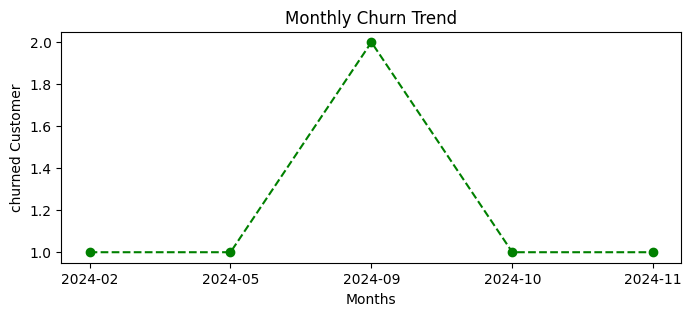

In [161]:
#4.1 Monthly churn trends (time series kpi)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='green',marker='o',linestyle = 'dashed')

plt.title('Monthly Churn Trend')
plt.xlabel('Months')
plt.ylabel('churned Customer')
plt.show()

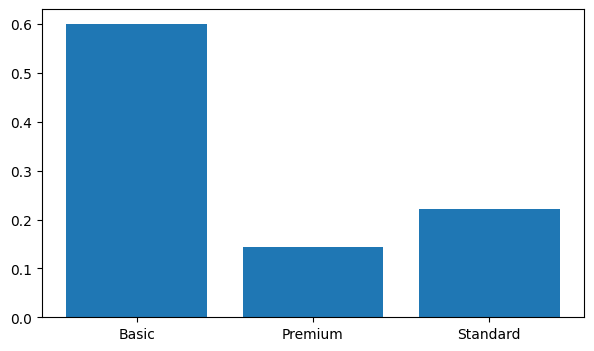

In [167]:
#4.2 churn by plan type 
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index,churn_plan.values)
plt.show()

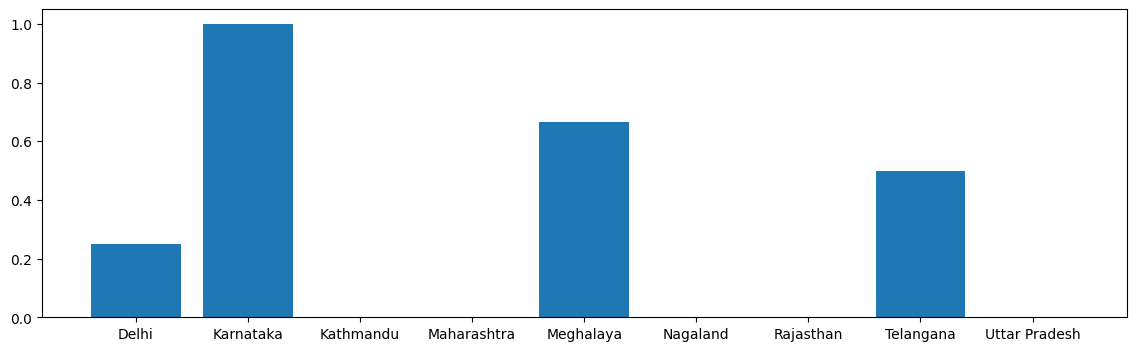

In [169]:
#4.3 churn by state 
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

plt.figure(figsize=(14,4))

plt.bar(churn_plan.index,churn_plan.values)
plt.show()


In [ ]:
#visualization using seaborn


In [172]:
#encoding -- convert str to numeric value so that we can find corr between features 
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [175]:
df_visual[['plan_type', 'contract_type','churn_score','churn_flag','escalations','churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,NaN,low
1,Premium,Annual,91,1,Y,high
2,Basic,Monthly,34,0,NaN,low
3,Premium,Annual,8,0,NaN,low
4,Standard,Monthly,88,1,Y,high


In [177]:
import warnings
warnings.filterwarnings("ignore")

In [185]:
#incorrect method of encoding  -- as numbers are not assigned based on priority

df_encoded = df_visual[['plan_type', 'contract_type','churn_score','churn_flag','escalations','churn_risk']].copy()
categorial_cols = ['plan_type','contract_type','churn_risk']

for col in categorial_cols:
    df_encoded[col] =  df_encoded[col].astype('category').cat.codes    

<Axes: >

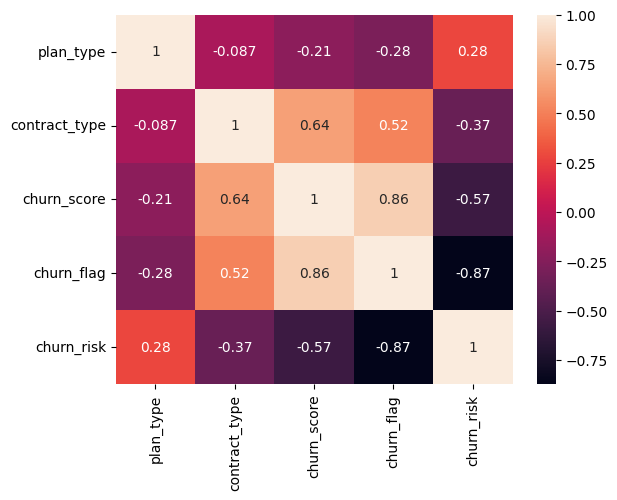

In [188]:
#heatmap (ccorrelation matrix )


#sns.heatmap(df_encoded.corr(),annot=True)
# Added numeric_only=True inside the corr() call
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True)


In [190]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'med'], dtype=object)

In [196]:
#correct method of encoding  --  based on priority

df_encoded = df_visual[['plan_type', 'contract_type','churn_score','churn_flag','escalations','churn_risk']].copy()
df_encoded['escalations'] = df_encoded['escalations'].fillna('N')
ordered_mappings = {
    'plan_type' : ['Basic','Standard','Premium'],
    'contract_type' : ['Monthly','Annual'],
    'churn_risk' : ['low', 'med', 'high'], 
    'escalations' : ['N', 'Y'] }

for col ,order in  ordered_mappings.items():
    df_encoded[col] =  pd.Categorical(df_encoded[col].astype('category'), categories=order , ordered=True).codes

In [197]:
df_visual[['plan_type', 'contract_type','churn_score','churn_flag','escalations','churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,NaN,low
1,Premium,Annual,91,1,Y,high
2,Basic,Monthly,34,0,NaN,low
3,Premium,Annual,8,0,NaN,low
4,Standard,Monthly,88,1,Y,high


In [198]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


<Axes: >

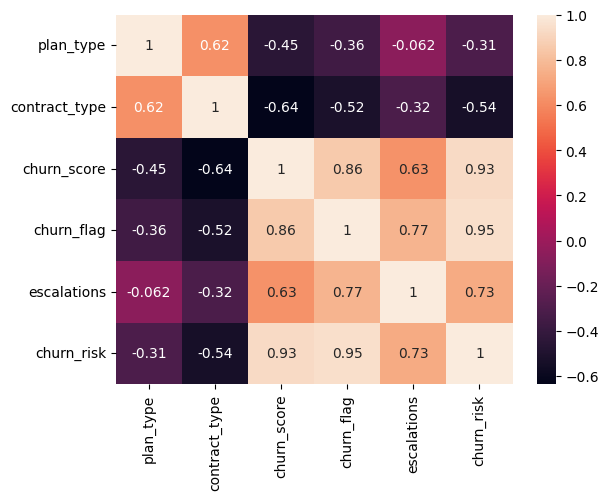

In [199]:
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True)

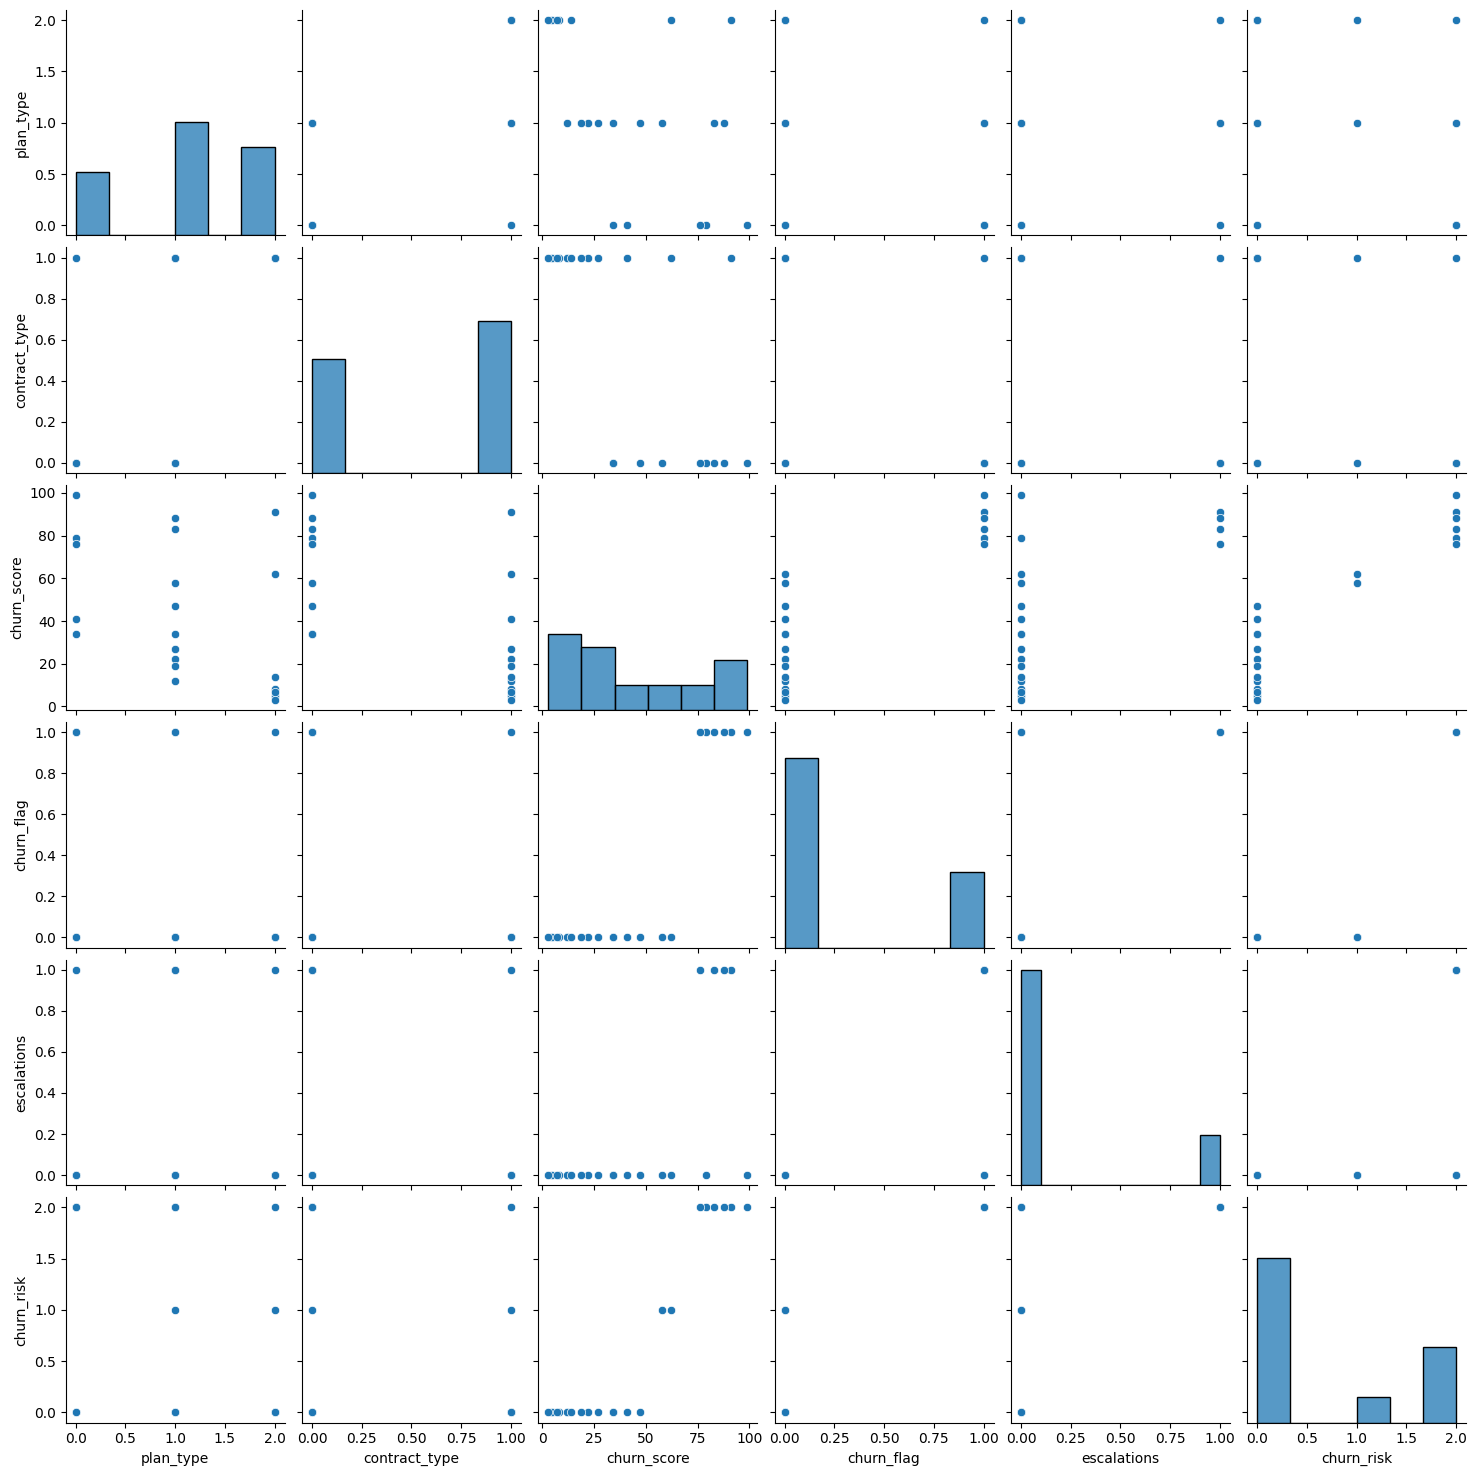

In [201]:
#pairplot -- relation ship in a dataset
sns.pairplot(df_encoded)

In [202]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

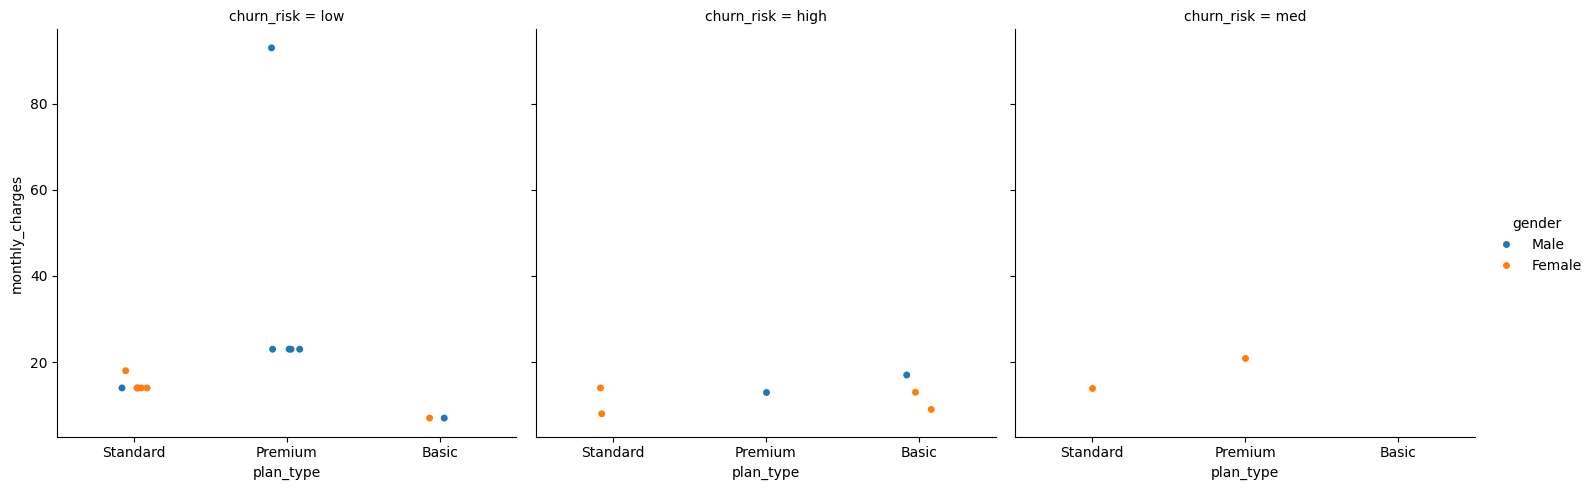

In [203]:
#catplot /facegrip plot == multi dimention comparision 

sns.catplot(data=df_visual,
           x='plan_type',
           y='monthly_charges', 
           hue= 'gender',
           col='churn_risk' )

In [204]:
#pivot table 


In [207]:
pd.pivot_table(
    df_visual, 
    values='churn_flag',
    index='plan_type',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [208]:
df_visual.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [215]:
pd.pivot_table(
    df_visual, 
     index='plan_type',
    values=['churn_flag','monthly_charges','customerid'],
    aggfunc = {
        'churn_flag' : 'mean',
        'monthly_charges' : 'sum',
        'customerid' : 'nunique'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [216]:
#working with sql and python (pandas)

In [217]:
#create db in sql 
conn = sqlite3.connect('test_database.sqlite')

#table details 
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTGER)")
#commit and saveabs
conn.commit()

In [224]:
#insert data 
cursor = conn.cursor()
cursor.execute("DELETE FROM users")
conn.commit()

cursor.execute(
    """
        INSERT INTO users VALUES
            ('sita','nepal',2000),
            ('ronish','nepal',10000),
            ('hari','nepal',5000)
        
    
    """ 
)
conn.commit()
print('data inserted successfully')

data inserted successfully


In [225]:
#check insserted data in table 
conn = sqlite3.connect('test_database.sqlite')
query = """ SELECT * FROM users"""
df_result =pd.read_sql(query,conn) 
df_result.head()

,first_name,country,budget
0,sita,nepal,2000
1,ronish,nepal,10000
2,hari,nepal,5000


In [226]:
#aggregation 
query = """
        SELECT country , sum(budget) as total_budget 
        FROM users
        GROUP BY country
        """ 
df_agg = pd.read_sql(query,conn)
df_agg

,country,total_budget
0,nepal,17000


In [227]:
#always close the conn with db once the task is over 
conn.close()